# Bayesian AB Testing

#### MA 03/22/2026

## Problem Framing

Given observed conversion rates for landing pages A, B. What is the posterior distribution of each conversion rate?
What is the probability B beats A, and what decision would we make under uncertainty?

### Observed Data
- Landing page A: 42 conversions out of 400 visitors
- Landing page B: 55 conversions out of 390 visitors

### Questions
- What is the posterior conversion rates?
- What is $P(\theta_B > \theta_A \mid \text{data})$?
- What decision does the posterior support?

## Closed-Form Beta-Binomial Updating

### Model Setup

- prior

$\theta_A \sim \text{Beta}(\alpha, \beta)$

$\theta_B \sim \text{Beta}(\alpha, \beta)$

- likelihood

$y_A \mid \theta_A \sim \text{Binomial}(n_A, \theta_A)$

$y_B \mid \theta_B \sim \text{Binomial}(n_B, \theta_B)$

- posterior

$P(\theta_A) \mid \text{data} \propto p(y_A \mid \theta_A)\,p(\theta_A)$

$P(\theta_B) \mid \text{data} \propto p(y_B \mid \theta_B)\,p(\theta_B)$

- Beta-Binomial conjugacy

$\theta_A \mid \text{data} \sim \text{Beta}(\alpha + y_A,\ \beta + n_A - y_A)$

$\theta_B \mid \text{data} \sim \text{Beta}(\alpha + y_B,\ \beta + n_B - y_B)$

### Sample from both posterior distributions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Observed data
n_A = 400
y_A = 42

n_B = 390
y_B = 55

# Prior
alpha = 1
beta = 1

# Posterior parameters
alpha_A_post = alpha + y_A
beta_A_post = beta + n_A - y_A

alpha_B_post = alpha + y_B
beta_B_post = beta + n_B - y_B

print("Posterior for A: Beta({}, {})".format(alpha_A_post, beta_A_post))
print("Posterior for B: Beta({}, {})".format(alpha_B_post, beta_B_post))

# drawing samples from the posterior
n_samples = 100_000

theta_A_samples = np.random.beta(alpha_A_post, beta_A_post, size=n_samples)
theta_B_samples = np.random.beta(alpha_B_post, beta_B_post, size=n_samples)


Posterior for A: Beta(43, 359)
Posterior for B: Beta(56, 336)


- theta_A_samples is a large set of plausible conversion rates for A
- theta_B_samples is a large set of plausible conversion rates for B
- together they approximate teh posterior distribution

### Estimate Posterior Mean
- Posterior mean is just the average of the posterior samples

In [2]:
posterior_mean_A = theta_A_samples.mean()
posterior_mean_B = theta_B_samples.mean()

print("Posterior mean for A:", posterior_mean_A)
print("Posterior mean for B:", posterior_mean_B)

Posterior mean for A: 0.10695524928344956
Posterior mean for B: 0.1427934190766608


- This is the bayesian estimate of each landing page's conversion rate after combining the prior belief and observed data

### Compute a 95% credible interval
- the interval containing 95% of the posterior mass

In [3]:
ci_A = np.quantile(theta_A_samples, [0.025, 0.975])
ci_B = np.quantile(theta_B_samples, [0.025, 0.975])

print("95% credible interval for A:", ci_A)
print("95% credible interval for B:", ci_B)

95% credible interval for A: [0.07861613 0.1387555 ]
95% credible interval for B: [0.11000782 0.17893813]


- given the model and the data, there is a 95% posterior probability that the true converstion rate lies in this interval

### Probability that B beats A

$\text{Directly estimate } \text{P}(\theta_B > \theta_A \mid \text{ data})$

- this is done by checking how often sampled B values exceed sampled A values

In [4]:
prob_B_beats_A = np.mean(theta_B_samples > theta_A_samples)
print("P(B > A | data):"), prob_B_beats_A

P(B > A | data):


(None, np.float64(0.93798))

- based on the posterior, B has a 93.8% probability of outperforming A

### Posterior Distribution of Lift

- lift is $\theta_B - \theta_A$

- this tells you not just that B is better, but by how much

In [5]:
lift_samples = theta_B_samples - theta_A_samples
expected_lift = lift_samples.mean()
lift_ci = np.quantile(lift_samples, [0.025, 0.975])

print("Expected lift:", expected_lift)
print("95% credible interval for lift:", lift_ci)

Expected lift: 0.03583816979321123
95% credible interval for lift: [-0.00995964  0.08196964]


- positive lift means B likely outperforms A
- negative lift means A likely outperforms B
- if the interval includes 0, uncertainty is still meaningful

## Posterior Summaries

In [6]:
summary_df = pd.DataFrame({
    "Variant": ["A", "B"],
    "Posterior Mean": [posterior_mean_A, posterior_mean_B],
    "95% CI Lower": [ci_A[0], ci_B[0]],
    "95% CI Upper": [ci_A[1], ci_B[1]],
})

summary_df

,Variant,Posterior Mean,95% CI Lower,95% CI Upper
0,A,0.106955,0.078616,0.138756
1,B,0.142793,0.110008,0.178938


## Visualization

- estimatations to distributions

### Posterior density for A and B

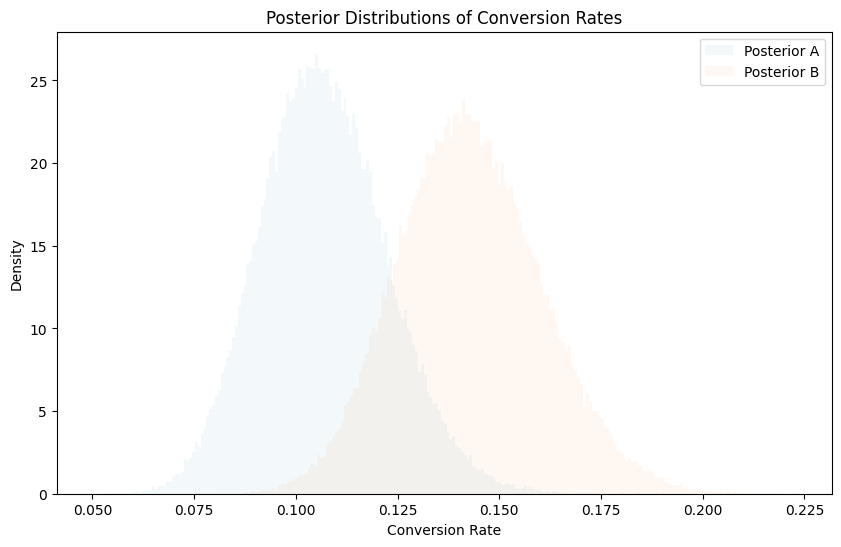

In [7]:
plt.figure(figsize=(10,6))
plt.hist(theta_A_samples, bins=200, density=True, alpha=0.05, label="Posterior A")
plt.hist(theta_B_samples, bins=200, density=True, alpha=0.05, label="Posterior B")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.title("Posterior Distributions of Conversion Rates")
plt.legend()
plt.show()

- where the plausible values for A and B lie
- how much overlap there is
- whether B is shifted to the right of A

### Histogram of Posterior Lift

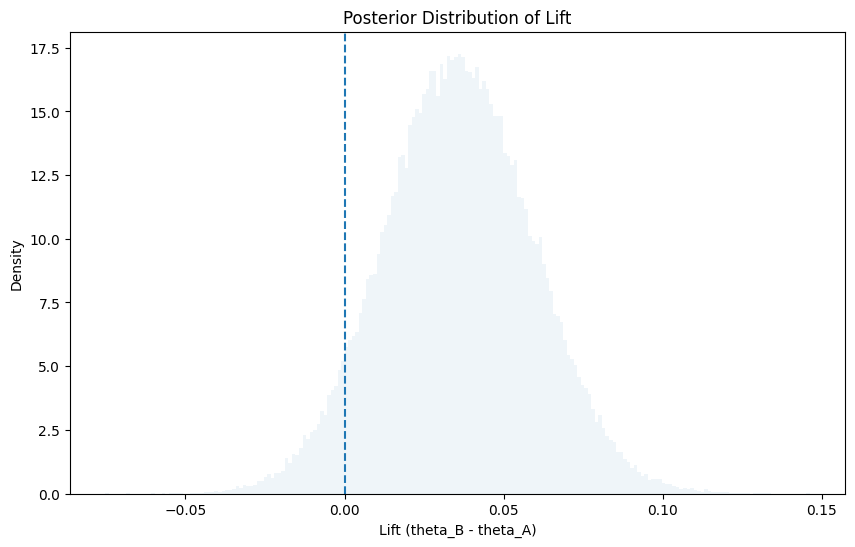

In [8]:
plt.figure(figsize=(10,6))
plt.hist(lift_samples, bins=200, density=True, alpha=0.07)
plt.axvline(0, linestyle="--")
plt.xlabel("Lift (theta_B - theta_A)")
plt.ylabel("Density")
plt.title("Posterior Distribution of Lift")
plt.show()

- if most of the lift distribution is above 0, B is likely better
- how large the likely improvement is
- how uncertain that improvement is

### Confidence that B beats A

- cumulative curve of lift

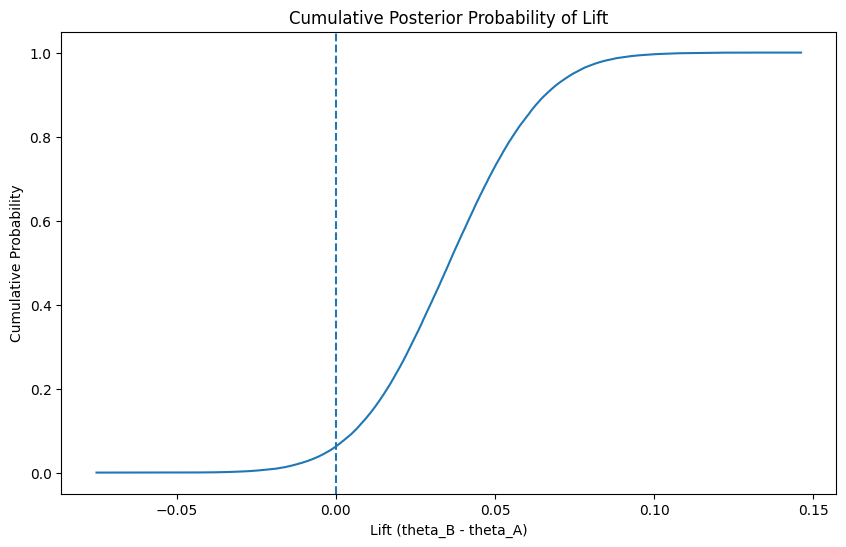

In [9]:
sorted_lift = np.sort(lift_samples)
cumulative_probs = np.arange(1, len(sorted_lift) + 1) / len(sorted_lift)

plt.figure(figsize=(10,6))
plt.plot(sorted_lift, cumulative_probs)
plt.axvline(0, linestyle="--")
plt.xlabel("Lift (theta_B - theta_A)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Posterior Probability of Lift")
plt.show()

- the value of the curve at 0 visualizes uncertainty around no improvement

## PyMC Version

- how real Bayesian ML work is often done

In [10]:
import pymc as pm
import arviz as az

with pm.Model() as ab_model:
    # Priors
    theta_A = pm.Beta("theta_A", alpha=1, beta=1)
    theta_B = pm.Beta("theta_B", alpha=1, beta=1)
    
    # Likelihoods
    obs_A = pm.Binomial("obs_A", n=n_A, p=theta_A, observed=y_A)
    obs_B = pm.Binomial("obs_B", n=n_B, p=theta_B, observed=y_B)
    
    # Derived quanitity: lift
    lift = pm.Deterministic("lift", theta_B - theta_A)
    
    # Sample from posterior
    trace = pm.sample(2000, tune=2000, target_accept=0.95, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta_A, theta_B]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


In [11]:
az.summary(trace, var_names=["theta_A", "theta_B", "lift"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_A,0.107,0.016,0.079,0.137,0.0,0.0,4481.0,4358.0,1.0
theta_B,0.143,0.018,0.110,0.177,0.0,0.0,5301.0,4573.0,1.0
lift,0.036,0.024,-0.008,0.080,0.0,0.0,5396.0,4999.0,1.0


- posterior mean, standard deviation, credible intervals, diagnostics, mean, HDI interval, whether lift is mostly positive

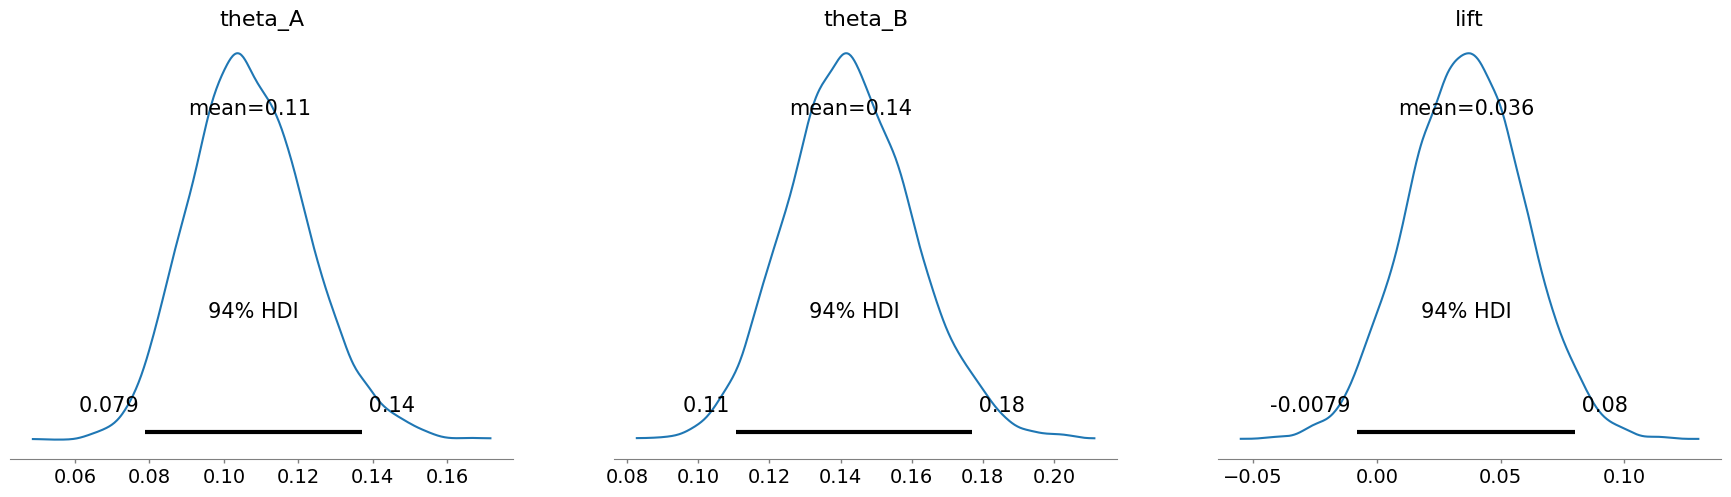

In [12]:
az.plot_posterior(trace, var_names=["theta_A", "theta_B", "lift"])
plt.show()

### compute probability B > A for PyMC draws

In [13]:
theta_A_draws = trace.posterior["theta_A"].values.flatten()
theta_B_draws = trace.posterior["theta_B"].values.flatten()
lift_draws = trace.posterior["lift"].values.flatten()

prob_B_beats_A_pymc = np.mean(theta_B_draws > theta_A_draws)
print("PyMC estimate of P(theta_B > theta_A | data):", prob_B_beats_A_pymc)


PyMC estimate of P(theta_B > theta_A | data): 0.93675


## Decision Interpretation

- what does the prior say?
- how certain are we?
- what action would that support?

In [14]:
print("Posterior mean A:", posterior_mean_A)
print("Posterior mean B:", posterior_mean_B)
print("95% CI A:", ci_A)
print("95% CI B:", ci_B)
print("Probability B > A:", prob_B_beats_A)
print("Expected lift:", expected_lift)
print("95% lift CI:", lift_ci)

Posterior mean A: 0.10695524928344956
Posterior mean B: 0.1427934190766608
95% CI A: [0.07861613 0.1387555 ]
95% CI B: [0.11000782 0.17893813]
Probability B > A: 0.93798
Expected lift: 0.03583816979321123
95% lift CI: [-0.00995964  0.08196964]


#### The posterior mean converstion rate for B is higher than for variant A. Based on the posterior simulation, the probability that B outperforms A is 0.93735 or 93.735%. The estimated lift, defined as $\theta_B - \theta_A$, is positive on average, suggesting that variant B likely improves conversions. However uncertainty remains, as the CI for the conversion rates still overlap and the posterior lift distribution may include values close to zero. A reasonable decision rule would be to ship variant B only if the posterior probability that it beats A exceeds a threshold such as 90%, or if the expected lift is large enough to justify implementation costs.

#### MA 03/22/2026